In [37]:
import os
import re
import random
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import layers, models

In [ ]:
df = pd.read_csv(r"C:\deep learning project\tmdb_text_image_only finall  (1).csv")  
df = df.dropna()

df.head()

,overview_enhanced,label,tmdb_id,title,poster_path
0,have you ever done a handstand on the tips of ...,Action,68902,Shaolin: Wheel of Life,/jJdCMsK9QAP4BMP2I9GYBnjx93f.jpg
1,when the head of a notorious crime family is m...,Action,1096563,End of Loyalty,/c4QA1rFQcyBZKaOOdUrDeL1G9Er.jpg
2,jack santos is a retired undercover vice cop w...,Action,1102332,Jack's Law,/qKxC5DXUhgKwRxmyBHDC8muWoly.jpg
3,cassie the last remaining member of the origin...,Action,89828,Gang of Roses 2: Next Generation,/g6KGKjw74YSfdmYpXI5IEbVr0OJ.jpg
4,in a timeless city a man with no name returns ...,Action,19206,The Perfect Sleep,/zv46BDUwdMjnj4evC8q3j7j95VM.jpg


In [ ]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-zA-Z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()


df["text"] = df["overview_enhanced"].apply(clean_text)

In [41]:

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df["label_id"] = le.fit_transform(df["label"])

num_classes = len(le.classes_)
print(le.classes_)

['Action' 'Comedy' 'Horror' 'Romance']


In [42]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label_id"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label_id"],
    random_state=42
)

In [43]:
MAX_WORDS = 15000
MAX_LEN = 120

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(train_df["text"])

def encode_text(texts):
    seq = tokenizer.texts_to_sequences(texts)
    return pad_sequences(seq, maxlen=MAX_LEN, padding="post")

In [44]:
DATASET_DIR = r"C:\deep learning project\dataset"
IMG_SIZE = 224

image_index = {}

for root, dirs, files in os.walk(DATASET_DIR):
    for file in files:
        image_index[file] = os.path.join(root, file)

In [45]:
def load_image(path):
    filename = path.split("/")[-1]
    full_path = image_index.get(filename)

    if full_path is None:
        return tf.zeros((IMG_SIZE, IMG_SIZE, 3))

    img = tf.io.read_file(full_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    return img / 255.0

In [55]:
def generator(data, batch_size=16):
    while True:
        data = data.sample(frac=1)

        for i in range(0, len(data), batch_size):
            batch = data.iloc[i:i+batch_size]

            texts = encode_text(batch["text"].tolist())

            images = np.array([
                load_image(p).numpy() for p in batch["poster_path"]
            ])

            labels = tf.keras.utils.to_categorical(
                batch["label_id"], num_classes
            )

            yield (
                {
                    "image": images,
                    "text": texts
                },
                labels
            )

In [56]:
# IMAGE BRANCH
image_input = layers.Input(shape=(224,224,3), name="image")
text_input = layers.Input(shape=(MAX_LEN,), name="text")

base = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_tensor=image_input
)

base.trainable = True
for layer in base.layers[:-30]:
    layer.trainable = False

img = layers.GlobalAveragePooling2D()(base.output)
img = layers.Dense(256, activation="relu")(img)
img = layers.BatchNormalization()(img)
img = layers.Dropout(0.4)(img)

# TEXT BRANCH

x = layers.Embedding(MAX_WORDS, 128)(text_input)
x = layers.Bidirectional(layers.LSTM(64))(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.4)(x)

# FUSION
combined = layers.Concatenate()([img, x])
combined = layers.Dense(256, activation="relu")(combined)
combined = layers.BatchNormalization()(combined)
combined = layers.Dropout(0.5)(combined)

output = layers.Dense(num_classes, activation="softmax")(combined)

model = models.Model(inputs=[image_input, text_input], outputs=output)
model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image (InputLayer)  │ (None, 224, 224,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_8         │ (None, 224, 224,  │          0 │ image[0][0]       │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_4     │ (None, 224, 224,  │          7 │ rescaling_8[0][0] │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_9         │ (None, 224, 224,  │          0 │ normalization_4[… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_9[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 6,514,983 (24.85 MB)

 Trainable params: 3,960,292 (15.11 MB)

 Non-trainable params: 2,554,691 (9.75 MB)

In [57]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [58]:
batch_size = 16

train_gen = generator(train_df, batch_size)
val_gen = generator(val_df, batch_size)

steps_train = len(train_df)//batch_size
steps_val = len(val_df)//batch_size

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,
    steps_per_epoch=steps_train,
    validation_steps=steps_val,
    verbose=1
)

Epoch 1/10
355/355 ━━━━━━━━━━━━━━━━━━━━ 222s 591ms/step - accuracy: 0.2685 - loss: 2.2721 - val_accuracy: 0.2673 - val_loss: 1.6053
Epoch 2/10
355/355 ━━━━━━━━━━━━━━━━━━━━ 392s 1s/step - accuracy: 0.2699 - loss: 2.1703 - val_accuracy: 0.3158 - val_loss: 1.3577
Epoch 3/10
355/355 ━━━━━━━━━━━━━━━━━━━━ 404s 1s/step - accuracy: 0.2803 - loss: 2.0602 - val_accuracy: 0.3849 - val_loss: 1.3267
Epoch 4/10
355/355 ━━━━━━━━━━━━━━━━━━━━ 473s 1s/step - accuracy: 0.2822 - loss: 2.0370 - val_accuracy: 0.3807 - val_loss: 1.2903
Epoch 5/10
355/355 ━━━━━━━━━━━━━━━━━━━━ 435s 1s/step - accuracy: 0.2924 - loss: 1.9711 - val_accuracy: 0.3741 - val_loss: 1.2736
Epoch 6/10
355/355 ━━━━━━━━━━━━━━━━━━━━ 381s 1s/step - accuracy: 0.3231 - loss: 1.8867 - val_accuracy: 0.4655 - val_loss: 1.1647
Epoch 7/10
355/355 ━━━━━━━━━━━━━━━━━━━━ 261s 736ms/step - accuracy: 0.6367 - loss: 0.9782 - val_accuracy: 0.9958 - val_loss: 0.0435
Epoch 8/10
355/355 ━━━━━━━━━━━━━━━━━━━━ 267s 751ms/step - accuracy: 0.9320 - loss: 0.1966 -

In [59]:
print(len(set(train_df.index) & set(val_df.index)))

0


In [60]:
val_df["label"].value_counts()

label
Action     305
Romance    305
Horror     305
Comedy     304
Name: count, dtype: int64

In [61]:
train_df["label"].value_counts()

label
Comedy     1423
Horror     1422
Action     1422
Romance    1422
Name: count, dtype: int64

In [62]:
test_gen = generator(test_df, batch_size)

model.evaluate(test_gen, steps=len(test_df)//16)

76/76 ━━━━━━━━━━━━━━━━━━━━ 38s 498ms/step - accuracy: 0.9992 - loss: 0.0034


[0.0034353933297097683, 0.9991776347160339]

In [65]:
test_gen = generator(test_df, batch_size)

steps = len(test_df) // batch_size

loss, acc = model.evaluate(test_gen, steps=steps)

print("Final Loss:", loss)
print("Final Accuracy:", acc)

76/76 ━━━━━━━━━━━━━━━━━━━━ 51s 675ms/step - accuracy: 0.9992 - loss: 0.0034
Final Loss: 0.0034067200031131506
Final Accuracy: 0.9991776347160339


In [66]:
base.trainable = True

# نخلي أول layers ثابتة
for layer in base.layers[:-100]:
    layer.trainable = False

In [67]:
combined = layers.Dense(256, activation="relu",
                        kernel_regularizer=tf.keras.regularizers.l2(1e-4))(combined)

In [68]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [69]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        verbose=1
    )
]

In [70]:
history_fine = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,
    steps_per_epoch=steps_train,
    validation_steps=steps_val,
    callbacks=callbacks
)

Epoch 1/10
355/355 ━━━━━━━━━━━━━━━━━━━━ 258s 695ms/step - accuracy: 0.9873 - loss: 0.0451 - val_accuracy: 0.9983 - val_loss: 0.0026 - learning_rate: 1.0000e-05
Epoch 2/10
355/355 ━━━━━━━━━━━━━━━━━━━━ 374s 1s/step - accuracy: 0.9914 - loss: 0.0353 - val_accuracy: 0.9992 - val_loss: 0.0020 - learning_rate: 1.0000e-05
Epoch 3/10
355/355 ━━━━━━━━━━━━━━━━━━━━ 266s 750ms/step - accuracy: 0.9926 - loss: 0.0287 - val_accuracy: 1.0000 - val_loss: 0.0012 - learning_rate: 1.0000e-05
Epoch 4/10
355/355 ━━━━━━━━━━━━━━━━━━━━ 289s 814ms/step - accuracy: 0.9937 - loss: 0.0253 - val_accuracy: 0.9992 - val_loss: 0.0037 - learning_rate: 1.0000e-05
Epoch 5/10
355/355 ━━━━━━━━━━━━━━━━━━━━ 0s 693ms/step - accuracy: 0.9961 - loss: 0.0199
Epoch 5: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
355/355 ━━━━━━━━━━━━━━━━━━━━ 285s 804ms/step - accuracy: 0.9959 - loss: 0.0181 - val_accuracy: 0.9992 - val_loss: 0.0017 - learning_rate: 1.0000e-05
Epoch 6/10
355/355 ━━━━━━━━━━━━━━━━━━━━ 278s 782ms

In [71]:
# اعادة تجهيز test بشكل ثابت بدون shuffle عشوائي
test_df = test_df.reset_index(drop=True)

In [72]:
test_gen = generator(test_df, batch_size=16)

steps = len(test_df) // 16

loss, acc = model.evaluate(test_gen, steps=steps, verbose=1)

print("Test Loss:", loss)
print("Test Accuracy:", acc)

76/76 ━━━━━━━━━━━━━━━━━━━━ 49s 653ms/step - accuracy: 0.9992 - loss: 0.0014
Test Loss: 0.001443039975129068
Test Accuracy: 0.9991776347160339


In [73]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

y_true = []
y_pred = []

test_gen = generator(test_df, batch_size=16)
steps = len(test_df) // 16

for i in range(steps):
    x, y = next(test_gen)
    pred = model.predict(x, verbose=0)

    y_true.extend(np.argmax(y, axis=1))
    y_pred.extend(np.argmax(pred, axis=1))

print(confusion_matrix(y_true, y_pred))

[[305   0   0   0]
 [  0 304   1   0]
 [  0   0 304   0]
 [  0   0   0 302]]


In [74]:
print(classification_report(
    y_true,
    y_pred,
    target_names=le.classes_
))

              precision    recall  f1-score   support

      Action       1.00      1.00      1.00       305
      Comedy       1.00      1.00      1.00       305
      Horror       1.00      1.00      1.00       304
     Romance       1.00      1.00      1.00       302

    accuracy                           1.00      1216
   macro avg       1.00      1.00      1.00      1216
weighted avg       1.00      1.00      1.00      1216



In [75]:
for i in range(5):
    x, y = next(test_gen)
    pred = model.predict(x, verbose=0)

    print("True:", np.argmax(y, axis=1))
    print("Pred:", np.argmax(pred, axis=1))
    print("-"*50)

True: [3 3 3 2]
Pred: [3 3 3 2]
--------------------------------------------------
True: [0 2 2 3 0 2 1 2 0 2 2 3 0 3 3 0]
Pred: [0 2 2 3 0 2 1 2 0 2 2 3 0 3 3 0]
--------------------------------------------------
True: [0 3 3 3 0 2 0 2 2 1 2 3 3 2 0 2]
Pred: [0 3 3 3 0 2 0 2 2 1 2 3 3 2 0 2]
--------------------------------------------------
True: [2 3 1 1 2 3 3 1 2 0 0 1 2 2 1 1]
Pred: [2 3 1 1 2 3 3 1 2 0 0 1 2 2 1 1]
--------------------------------------------------
True: [1 3 1 1 0 2 0 1 1 2 3 1 0 0 3 2]
Pred: [1 3 1 1 0 2 0 1 1 2 3 1 0 0 3 2]
--------------------------------------------------


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 290ms/step
TEXT:
a of guardians are tasked with a messenger who must deliver vital information to their king on their deadly an they face incredible danger as they plague ridden outcasts vile monsters fight battle mis ...


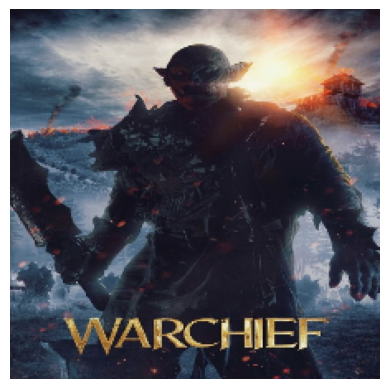

TRUE LABEL: Action
PRED LABEL: Action
TEXT:
tough sexy hellcat member kat gets a crime didn commit sent to a gruesome women s prison ruled by a maniacal warden must fight her way out in order to get her revenge ruthless and sadistic gang rosie  ...


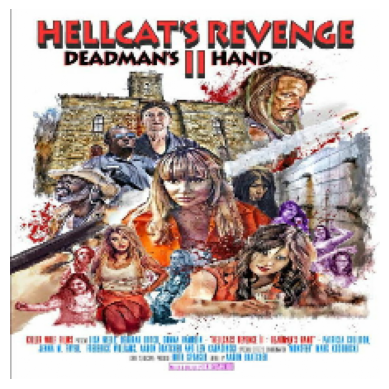

TRUE LABEL: Action
PRED LABEL: Action
TEXT:
theres trouble brewing in downtown coventry mobster ray carlton has a dreamcasinos hes got dirt the local mayor derek osbourne he wants his pound of in for not down the toilet carlton has the mayor gr ...


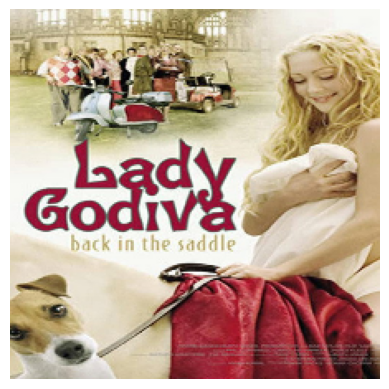

TRUE LABEL: Comedy
PRED LABEL: Comedy
TEXT:
darcy a talented event to her home to plan her mother s wedding she s having accepting her stepfather to be and quickly darcy s obsession with perfection begins to clash with her s for a key especiall ...


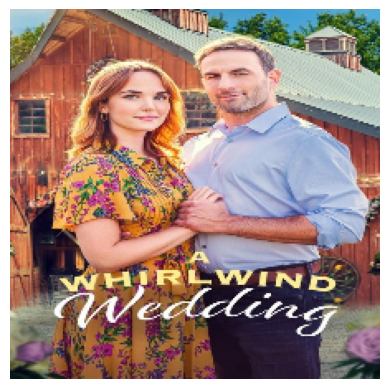

TRUE LABEL: Romance
PRED LABEL: Romance
TEXT:
a crew of space investigates a asteroid that is covered by what appear to be hieroglyphics their open of pure darkness an ancient god is hell bent on destroying all things spawned from the light the c ...


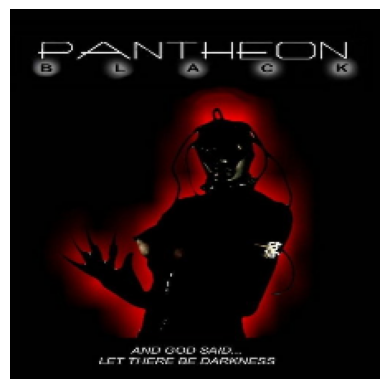

TRUE LABEL: Horror
PRED LABEL: Horror
TEXT:
frank a veteran cop is being hunted by fellow police officers after they learned has betrayed the brotherhood and exposed to the feds wide scale corruption of lapd he one left to prove case and surviv ...


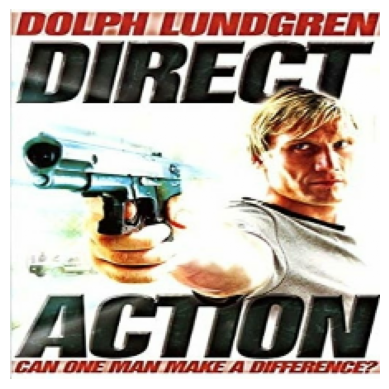

TRUE LABEL: Action
PRED LABEL: Action
TEXT:
bookstore owner emma believes in fairy tales although has yet to be swept away by prince she sees real knight in shining armor potential with a new landon as emma time with landon her with consultant  ...


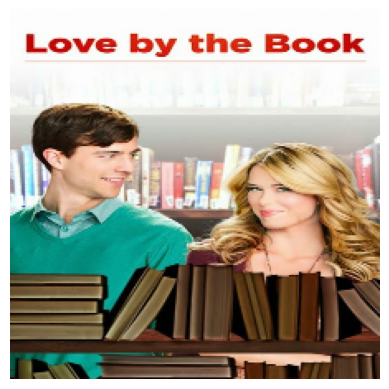

TRUE LABEL: Romance
PRED LABEL: Romance
TEXT:
a small oregon town is chosen be the new headquarters of neo genentrix nefarious genocidal ceo unleashes a genetic that converts most the inhabitants of skyhook into unsatisfied with anything less tha ...


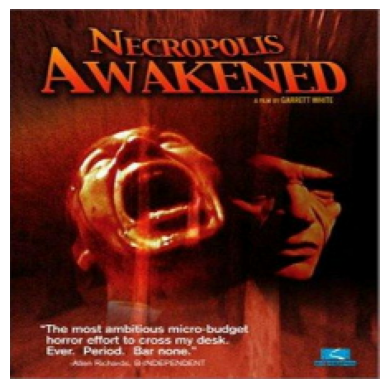

TRUE LABEL: Horror
PRED LABEL: Horror
TEXT:
jacob bradley wakes up in a warehouse the midst of tactical with no memory and idea he is he is found by a young him escape and tells that no matter what happens he must survive a organization on the  ...


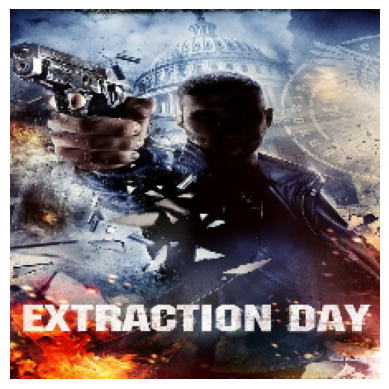

TRUE LABEL: Action
PRED LABEL: Action
TEXT:
dive the enchanting world of ovo where a charming captures the heart a quirky insect in a vibrant neighborhood this dazzling you in a bustling ecosystem brimming with life the extraordinary adventures ...


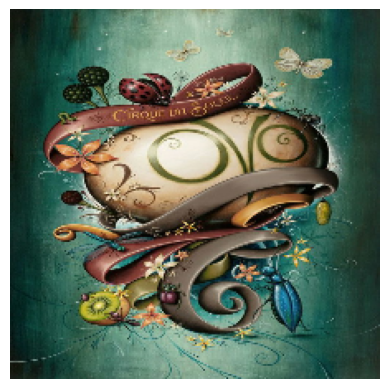

TRUE LABEL: Comedy
PRED LABEL: Comedy


In [80]:
import numpy as np
import matplotlib.pyplot as plt

def decode_label(x):
    return le.inverse_transform([x])[0]

test_sample = test_df.sample(10).reset_index(drop=True)

# تجهيز يدوي (مهم)
texts = encode_text(test_sample["text"])
images = np.array([load_image(p) for p in test_sample["poster_path"]])

pred = model.predict({"image": images, "text": texts})

y_pred = np.argmax(pred, axis=1)
y_true = test_sample["label_id"].values

for i in range(len(test_sample)):
    print("="*60)

    print("TEXT:")
    print(test_sample.iloc[i]["text"][:200], "...")

    plt.imshow(images[i])
    plt.axis("off")
    plt.show()

    print("TRUE LABEL:", decode_label(y_true[i]))
    print("PRED LABEL:", decode_label(y_pred[i]))